<a href="https://colab.research.google.com/github/ekttd/VAST-Challenge/blob/main/special_id.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Загрузка данных**

In [ ]:
import pandas as pd

In [ ]:
friday_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Fri.csv"
df_fri = pd.read_csv(friday_url)
df_fri.head()

,Timestamp,from,to,location
0,2014-6-06 08:03:19,439105,1053224,Kiddie Land
1,2014-6-06 08:03:19,439105,1696241,Kiddie Land
2,2014-6-06 08:03:19,439105,580064,Kiddie Land
3,2014-6-06 08:03:19,439105,1464748,Kiddie Land
4,2014-6-06 08:03:47,1836139,1593258,Entry Corridor


In [ ]:
saturday_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Sat.csv"
df_sat = pd.read_csv(saturday_url)
df_sat.head()

,Timestamp,from,to,location
0,2014-6-07 08:01:58,1003120,839736,Entry Corridor
1,2014-6-07 08:02:01,1743218,1202957,Entry Corridor
2,2014-6-07 08:02:39,1760095,external,Entry Corridor
3,2014-6-07 08:02:40,686125,839736,Entry Corridor
4,2014-6-07 08:02:45,2046019,269197,Entry Corridor


In [ ]:
sunday_url = "https://github.com/ekttd/VAST-Challenge/raw/main/MC2%202015%20Data/comm-data-Sun.csv"
df_sun = pd.read_csv(sunday_url)
df_sun.head()

,Timestamp,from,to,location
0,2014-6-08 08:01:05,1401601,839736,Kiddie Land
1,2014-6-08 08:01:16,1169163,600636,Entry Corridor
2,2014-6-08 08:01:16,1169163,1561994,Entry Corridor
3,2014-6-08 08:01:16,1169163,864634,Entry Corridor
4,2014-6-08 08:01:16,1169163,577530,Entry Corridor


# **Преобразование данных**

---
Добавлены интервалы по 15 минут для визуалаизации


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Функция для преобразования одного дня
def prepare_day_data(df_day, day_name):
    """Преобразует данные одного дня, добавляя quarter от начала дня"""
    df = df_day.copy()

    # Преобразуем Timestamp
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])

    # Начало дня (00:00 этого дня)
    day_start = pd.Timestamp(f"{df['Timestamp'].dt.date.iloc[0]} 00:00:00")

    # Минуты от начала дня
    minutes_from_start = (df['Timestamp'] - day_start).dt.total_seconds() // 60

    # Номер 15-минутного интервала (1-96)
    df['quarter'] = (minutes_from_start // 15 + 1).astype(int)

    # Добавляем час и минуту
    df['hour'] = df['Timestamp'].dt.hour
    df['minute'] = df['Timestamp'].dt.minute

    # Удаляем Timestamp (как в исходном коде)
    df = df.drop(columns=['Timestamp'])

    return df

In [ ]:
# Преобразуем каждый день отдельно

df_fri_processed = prepare_day_data(df_fri, 'Friday')
df_sat_processed = prepare_day_data(df_sat, 'Saturday')
df_sun_processed = prepare_day_data(df_sun, 'Sunday')

print("Пятница (первые 5 строк):")
print(df_fri_processed.head())
print("\nСуббота (первые 5 строк):")
print(df_sat_processed.head())
print("\nВоскресенье (первые 5 строк):")
print(df_sun_processed.head())

Пятница (первые 5 строк):
      from       to        location  quarter  hour  minute
0   439105  1053224     Kiddie Land       33     8       3
1   439105  1696241     Kiddie Land       33     8       3
2   439105   580064     Kiddie Land       33     8       3
3   439105  1464748     Kiddie Land       33     8       3
4  1836139  1593258  Entry Corridor       33     8       3

Суббота (первые 5 строк):
      from        to        location  quarter  hour  minute
0  1003120    839736  Entry Corridor       33     8       1
1  1743218   1202957  Entry Corridor       33     8       2
2  1760095  external  Entry Corridor       33     8       2
3   686125    839736  Entry Corridor       33     8       2
4  2046019    269197  Entry Corridor       33     8       2

Воскресенье (первые 5 строк):
      from       to        location  quarter  hour  minute
0  1401601   839736     Kiddie Land       33     8       1
1  1169163   600636  Entry Corridor       33     8       1
2  1169163  1561994  Entr

In [ ]:
# Получаем количество сообщений по интервалам для каждого дня

# Для пятницы
fri_quarters = df_fri_processed['quarter'].value_counts().sort_index()
# Заполняем все 96 интервалов
all_quarters = range(1, 97)
fri_counts = fri_quarters.reindex(all_quarters, fill_value=0)

# Для субботы
sat_quarters = df_sat_processed['quarter'].value_counts().sort_index()
sat_counts = sat_quarters.reindex(all_quarters, fill_value=0)

# Для воскресенья
sun_quarters = df_sun_processed['quarter'].value_counts().sort_index()
sun_counts = sun_quarters.reindex(all_quarters, fill_value=0)

# Создаем подписи времени (каждые 2 часа)
time_labels = []
for hour in range(0, 24, 2):
    time_labels.append(f"{hour:02d}:00")

In [ ]:
# Для каждого дня нормализуем относительно его собственного максимума
fri_norm = fri_counts.values / fri_counts.max() if fri_counts.max() > 0 else fri_counts.values
sat_norm = sat_counts.values / sat_counts.max() if sat_counts.max() > 0 else sat_counts.values
sun_norm = sun_counts.values / sun_counts.max() if sun_counts.max() > 0 else sun_counts.values

print(f"Пятница: макс={fri_counts.max()}, мин={fri_counts.min()}")
print(f"Суббота: макс={sat_counts.max()}, мин={sat_counts.min()}")
print(f"Воскресенье: макс={sun_counts.max()}, мин={sun_counts.min()}")

Пятница: макс=27227, мин=0
Суббота: макс=44068, мин=0
Воскресенье: макс=65454, мин=0


# **Топ активных отправителей по дням**


---

С помощью диаграммы можно выделить id, с которых отправлялось больше всего сообщений

In [ ]:
massage_counts_fri = df_fri.groupby('from').size().sort_values(ascending=False)
massage_counts_fri.head(3)

,0
from,
1278894,38658
839736,5914
1508923,1896


In [ ]:
massage_counts_sat = df_sat.groupby('from').size().sort_values(ascending=False)
massage_counts_sat.head(3)

,0
from,
1278894,70143
839736,10224
1351786,2273


In [ ]:
massage_counts_sun = df_sun.groupby('from').size().sort_values(ascending=False)
massage_counts_sun.head(3)

,0
from,
1278894,81559
839736,44674
620184,1979


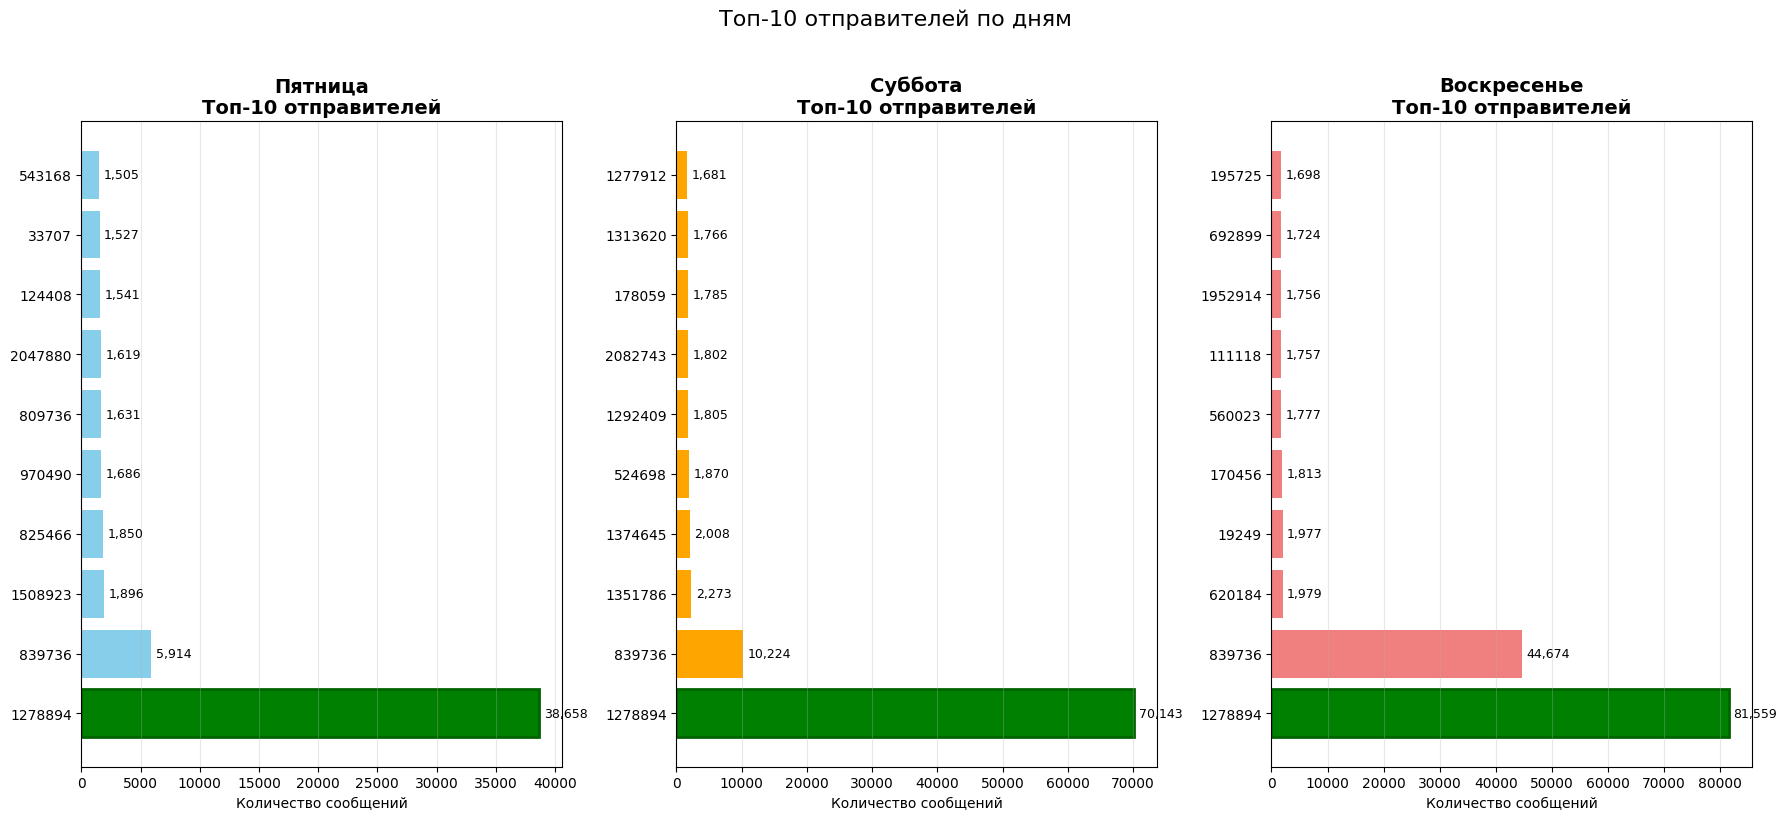

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

days_data = [
    ('Пятница', massage_counts_fri.head(10), axes[0], 'skyblue'),
    ('Суббота', massage_counts_sat.head(10), axes[1], 'orange'),
    ('Воскресенье', massage_counts_sun.head(10), axes[2], 'lightcoral')
]

for day_name, senders, ax, color in days_data:
    # Преобразуем ID в строки для подписей
    ids = [str(id) for id in senders.index]
    values = senders.values

    # Создаем горизонтальный бар-чарт
    bars = ax.barh(ids, values, color=color)

    # Добавляем значения на концах баров
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(val + max(values)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

    ax.set_xlabel('Количество сообщений')
    ax.set_title(f'{day_name}\nТоп-10 отправителей', fontsize=14, fontweight='bold')

    # Добавляем сетку для читаемости
    ax.grid(axis='x', alpha=0.3)

    # Подсвечиваем спамера 1278894 если он есть в топе
    if 1278894 in senders.index:
        idx = list(senders.index).index(1278894)
        bars[idx].set_color('green')
        bars[idx].set_edgecolor('darkgreen')
        bars[idx].set_linewidth(2)

plt.suptitle('Топ-10 отправителей по дням', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### В топе отправителей видно, что отправитель id=1278894 лидирует с огромным отрывом - на основе этого можно выдвинуть **гипотезу**: отпрваитель с id=1278894 совершает массовую рассылку сообщений либо для сотрудников, либо для посетителей (информация о предстоящих мероприятиях или акциях)

# **Активность спамера 1278894 по дням**


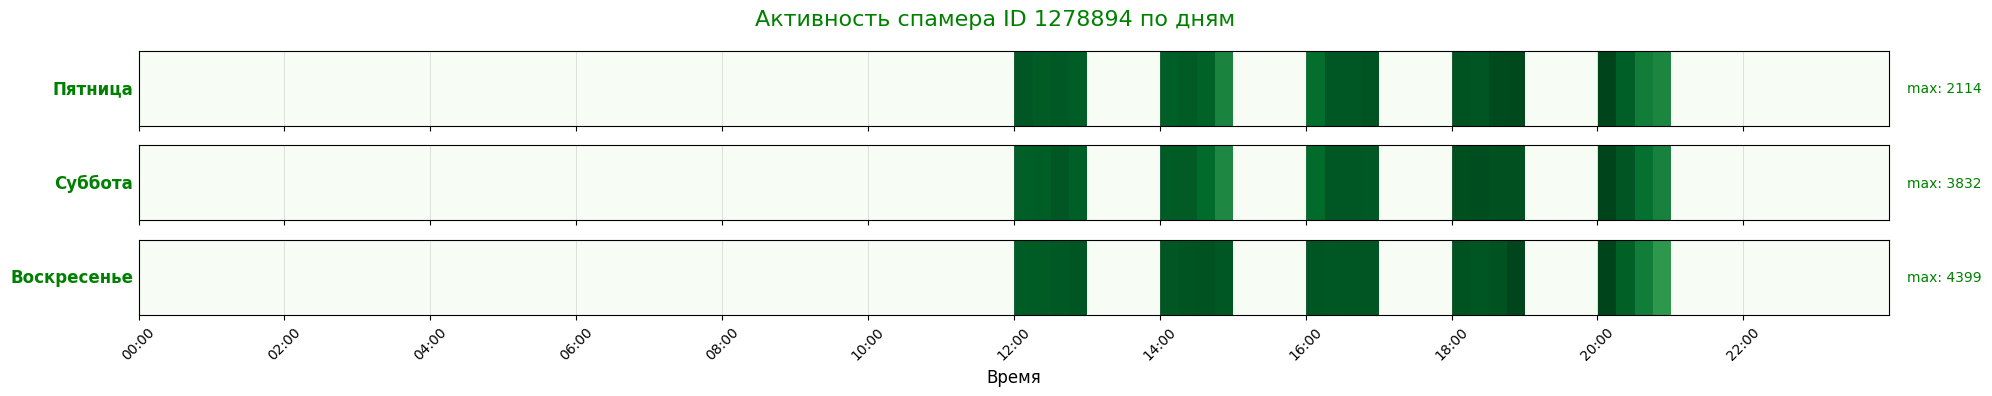

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(20, 4), sharex=True)

# Для каждого дня получаем активность спамера
spamer_days = [
    ('Пятница', df_fri_processed[df_fri_processed['from'] == 1278894], axes[0]),
    ('Суббота', df_sat_processed[df_sat_processed['from'] == 1278894], axes[1]),
    ('Воскресенье', df_sun_processed[df_sun_processed['from'] == 1278894], axes[2])
]

for i, (day_name, df_spamer, ax) in enumerate(spamer_days):
    # Считаем сообщения по интервалам
    if len(df_spamer) > 0:
        spamer_counts = df_spamer.groupby('quarter').size().reindex(all_quarters, fill_value=0)
        max_val = spamer_counts.max()
        norm_data = spamer_counts.values / max_val if max_val > 0 else spamer_counts.values
    else:
        spamer_counts = pd.Series(0, index=all_quarters)
        norm_data = spamer_counts.values
        max_val = 0

    # Отображаем
    im = ax.imshow([norm_data], cmap='Greens', aspect='auto', extent=[1, 97, 0, 1])

    ax.set_yticks([])
    ax.set_ylabel(day_name, fontsize=12, fontweight='bold', rotation=0, ha='right', va='center', color='green')
    ax.text(98, 0.5, f"max: {max_val}", va='center', fontsize=10, color='green')

    # Вертикальные линии
    for hour in range(0, 25, 2):
        quarter_pos = hour * 4 + 1
        if quarter_pos <= 97:
            ax.axvline(x=quarter_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

axes[2].set_xticks([1 + i*8 for i in range(12)])
axes[2].set_xticklabels(time_labels, rotation=45)
axes[2].set_xlabel('Время', fontsize=12)

plt.suptitle('Активность спамера ID 1278894 по дням', fontsize=16, y=0.98, color='green')
plt.tight_layout()
plt.show()

# **Анализ выделяющихся id**

In [ ]:
# Создаем подписи для интервалов (каждые 15 минут)
intervals = list(range(1, 97))

# Для каждого дня свой start_hour
start_hour_fri = pd.Timestamp("2014-06-06 00:00:00")
start_hour_sat = pd.Timestamp("2014-06-07 00:00:00")
start_hour_sun = pd.Timestamp("2014-06-08 00:00:00")

clock_labels = []
for q in intervals:
    time = start_hour_sun + pd.Timedelta(minutes=(q-1)*15)
    if q % 8 == 1:  # Каждые 2 часа
        clock_labels.append(time.strftime('%H:%M'))
    else:
        clock_labels.append("")

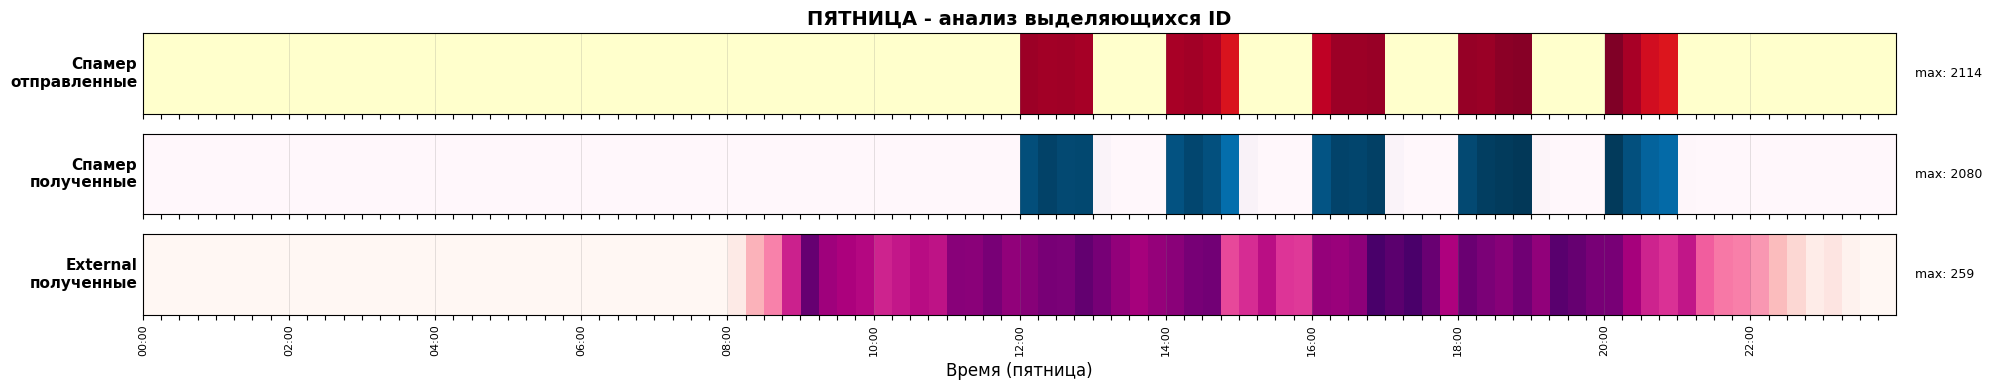

Пятница - спамер отправил: 2114, получил: 2080, external: 259


In [ ]:
# пятница
fig, axes = plt.subplots(3, 1, figsize=(20, 4), sharex=True)

# 1. Отправленные спамером (from = 1278894 - число)
df_spamer_sent = df_fri_processed[df_fri_processed["from"] == 1278894].copy()
spamer_sent_counts = df_spamer_sent.groupby("quarter").size().reindex(intervals, fill_value=0)
spamer_sent_max = spamer_sent_counts.max()
if spamer_sent_max > 0:
    spamer_sent_norm = spamer_sent_counts / spamer_sent_max
else:
    spamer_sent_norm = spamer_sent_counts

axes[0].imshow([spamer_sent_norm.values], cmap="YlOrRd", aspect="auto", extent=[1, 97, 0, 1])
axes[0].set_yticks([])
axes[0].set_ylabel("Спамер\nотправленные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
axes[0].text(98, 0.5, f"max: {spamer_sent_max}", va='center', fontsize=9)
axes[0].set_title("ПЯТНИЦА - анализ выделяющихся ID", fontsize=14, fontweight='bold')

# 2. Полученные спамером (to = '1278894' - строка)
df_spamer_rec = df_fri_processed[df_fri_processed["to"] == "1278894"].copy()
spamer_rec_counts = df_spamer_rec.groupby("quarter").size().reindex(intervals, fill_value=0)
spamer_rec_max = spamer_rec_counts.max()
if spamer_rec_max > 0:
    spamer_rec_norm = spamer_rec_counts / spamer_rec_max
else:
    spamer_rec_norm = spamer_rec_counts

axes[1].imshow([spamer_rec_norm.values], cmap="PuBu", aspect="auto", extent=[1, 97, 0, 1])
axes[1].set_yticks([])
axes[1].set_ylabel("Спамер\nполученные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
axes[1].text(98, 0.5, f"max: {spamer_rec_max}", va='center', fontsize=9)

# 3. Полученные external
df_external = df_fri_processed[df_fri_processed["to"] == "external"].copy()
external_counts = df_external.groupby("quarter").size().reindex(intervals, fill_value=0)
external_max = external_counts.max()
if external_max > 0:
    external_norm = external_counts / external_max
else:
    external_norm = external_counts

axes[2].imshow([external_norm.values], cmap="RdPu", aspect="auto", extent=[1, 97, 0, 1])
axes[2].set_yticks([])
axes[2].set_ylabel("External\nполученные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
axes[2].text(98, 0.5, f"max: {external_max}", va='center', fontsize=9)

# Вертикальные линии для часов
for ax in axes:
    for hour in range(0, 25, 2):
        quarter_pos = hour * 4 + 1
        if quarter_pos <= 97:
            ax.axvline(x=quarter_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# Настройка нижней оси
axes[2].set_xticks(intervals)
axes[2].set_xticklabels(clock_labels, rotation=90, fontsize=8)
axes[2].set_xlabel('Время (пятница)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Пятница - спамер отправил: {spamer_sent_max}, получил: {spamer_rec_max}, external: {external_max}")

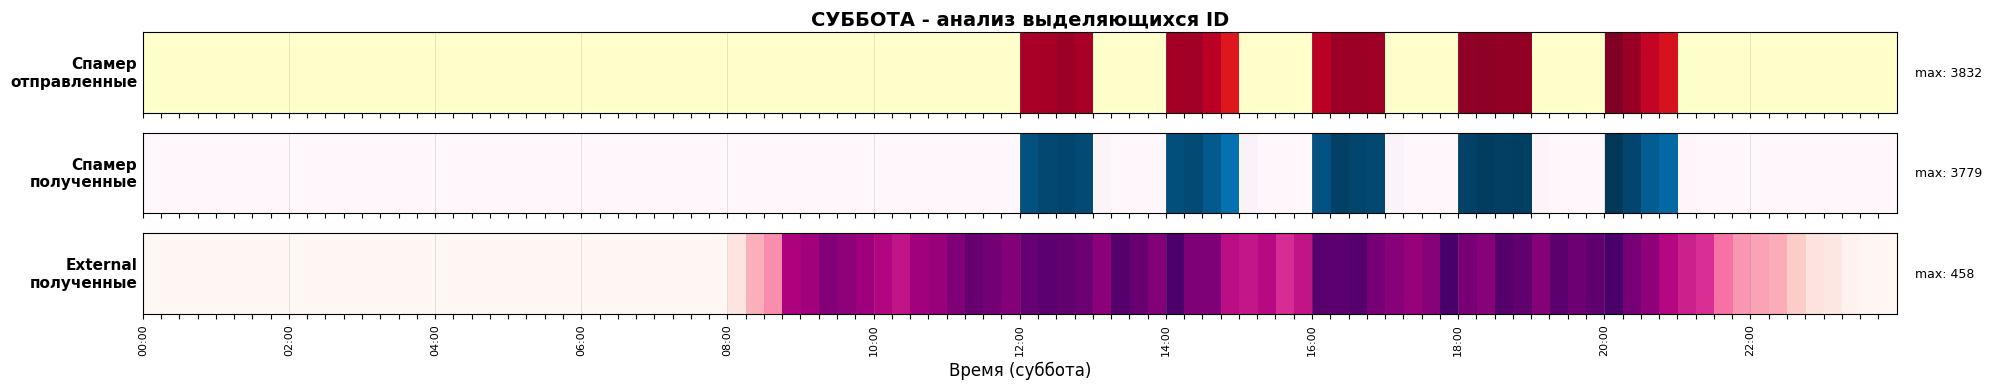

Суббота - спамер отправил: 3832, получил: 3779, external: 458


In [ ]:
# суббота
fig, axes = plt.subplots(3, 1, figsize=(20, 4), sharex=True)

# 1. Отправленные спамером
df_spamer_sent = df_sat_processed[df_sat_processed["from"] == 1278894].copy()
spamer_sent_counts = df_spamer_sent.groupby("quarter").size().reindex(intervals, fill_value=0)
spamer_sent_max = spamer_sent_counts.max()
if spamer_sent_max > 0:
    spamer_sent_norm = spamer_sent_counts / spamer_sent_max
else:
    spamer_sent_norm = spamer_sent_counts

axes[0].imshow([spamer_sent_norm.values], cmap="YlOrRd", aspect="auto", extent=[1, 97, 0, 1])
axes[0].set_yticks([])
axes[0].set_ylabel("Спамер\nотправленные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
axes[0].text(98, 0.5, f"max: {spamer_sent_max}", va='center', fontsize=9)
axes[0].set_title("СУББОТА - анализ выделяющихся ID", fontsize=14, fontweight='bold')

# 2. Полученные спамером (to = '1278894' - строка)
df_spamer_rec = df_sat_processed[df_sat_processed["to"] == "1278894"].copy()
spamer_rec_counts = df_spamer_rec.groupby("quarter").size().reindex(intervals, fill_value=0)
spamer_rec_max = spamer_rec_counts.max()
if spamer_rec_max > 0:
    spamer_rec_norm = spamer_rec_counts / spamer_rec_max
else:
    spamer_rec_norm = spamer_rec_counts

axes[1].imshow([spamer_rec_norm.values], cmap="PuBu", aspect="auto", extent=[1, 97, 0, 1])
axes[1].set_yticks([])
axes[1].set_ylabel("Спамер\nполученные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
axes[1].text(98, 0.5, f"max: {spamer_rec_max}", va='center', fontsize=9)

# 3. Полученные external
df_external = df_sat_processed[df_sat_processed["to"] == "external"].copy()
external_counts = df_external.groupby("quarter").size().reindex(intervals, fill_value=0)
external_max = external_counts.max()
if external_max > 0:
    external_norm = external_counts / external_max
else:
    external_norm = external_counts

axes[2].imshow([external_norm.values], cmap="RdPu", aspect="auto", extent=[1, 97, 0, 1])
axes[2].set_yticks([])
axes[2].set_ylabel("External\nполученные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
axes[2].text(98, 0.5, f"max: {external_max}", va='center', fontsize=9)

# Вертикальные линии для часов
for ax in axes:
    for hour in range(0, 25, 2):
        quarter_pos = hour * 4 + 1
        if quarter_pos <= 97:
            ax.axvline(x=quarter_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# Настройка нижней оси
axes[2].set_xticks(intervals)
axes[2].set_xticklabels(clock_labels, rotation=90, fontsize=8)
axes[2].set_xlabel('Время (суббота)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Суббота - спамер отправил: {spamer_sent_max}, получил: {spamer_rec_max}, external: {external_max}")

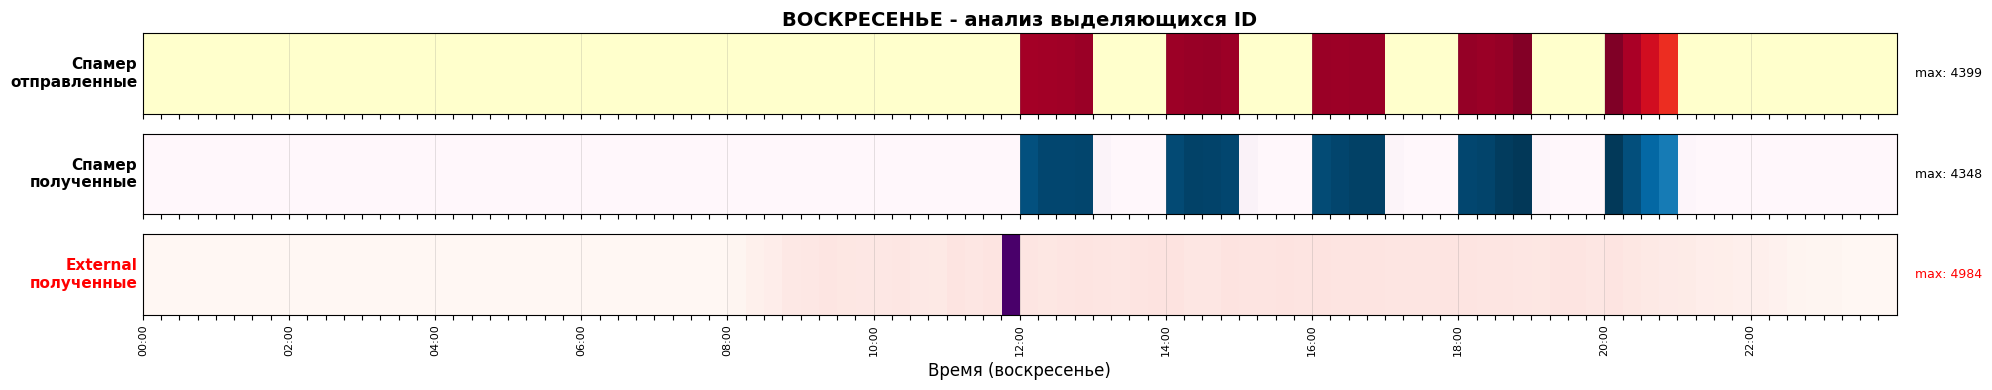

Воскресенье - спамер отправил: 4399, получил: 4348, external: 4984
Пик external: интервал 48 (11:45), 4984 сообщений


In [ ]:
# воскресенье
fig, axes = plt.subplots(3, 1, figsize=(20, 4), sharex=True)

# 1. Отправленные спамером
df_spamer_sent = df_sun_processed[df_sun_processed["from"] == 1278894].copy()
spamer_sent_counts = df_spamer_sent.groupby("quarter").size().reindex(intervals, fill_value=0)
spamer_sent_max = spamer_sent_counts.max()
if spamer_sent_max > 0:
    spamer_sent_norm = spamer_sent_counts / spamer_sent_max
else:
    spamer_sent_norm = spamer_sent_counts

axes[0].imshow([spamer_sent_norm.values], cmap="YlOrRd", aspect="auto", extent=[1, 97, 0, 1])
axes[0].set_yticks([])
axes[0].set_ylabel("Спамер\nотправленные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
axes[0].text(98, 0.5, f"max: {spamer_sent_max}", va='center', fontsize=9)
axes[0].set_title("ВОСКРЕСЕНЬЕ - анализ выделяющихся ID", fontsize=14, fontweight='bold')

# 2. Полученные спамером (to = '1278894' - строка)
df_spamer_rec = df_sun_processed[df_sun_processed["to"] == "1278894"].copy()
spamer_rec_counts = df_spamer_rec.groupby("quarter").size().reindex(intervals, fill_value=0)
spamer_rec_max = spamer_rec_counts.max()
if spamer_rec_max > 0:
    spamer_rec_norm = spamer_rec_counts / spamer_rec_max
else:
    spamer_rec_norm = spamer_rec_counts

axes[1].imshow([spamer_rec_norm.values], cmap="PuBu", aspect="auto", extent=[1, 97, 0, 1])
axes[1].set_yticks([])
axes[1].set_ylabel("Спамер\nполученные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center')
axes[1].text(98, 0.5, f"max: {spamer_rec_max}", va='center', fontsize=9)

# 3. Полученные external
df_external = df_sun_processed[df_sun_processed["to"] == "external"].copy()
external_counts = df_external.groupby("quarter").size().reindex(intervals, fill_value=0)
external_max = external_counts.max()
if external_max > 0:
    peak_q = external_counts.idxmax()
    peak_time = start_hour_sun + pd.Timedelta(minutes=(peak_q-1)*15)
    peak_hour = peak_time.hour
    peak_min = peak_time.minute
else:
    peak_q = None
    peak_hour = 0
    peak_min = 0
if external_max > 0:
    external_norm = external_counts / external_max
else:
    external_norm = external_counts

axes[2].imshow([external_norm.values], cmap="RdPu", aspect="auto", extent=[1, 97, 0, 1])
axes[2].set_yticks([])
axes[2].set_ylabel("External\nполученные", fontsize=11, fontweight='bold', rotation=0, ha='right', va='center', color='red')
axes[2].text(98, 0.5, f"max: {external_max}", va='center', fontsize=9, color='red')

# Вертикальные линии для часов
for ax in axes:
    for hour in range(0, 25, 2):
        quarter_pos = hour * 4 + 1
        if quarter_pos <= 97:
            ax.axvline(x=quarter_pos, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)


# Настройка нижней оси
axes[2].set_xticks(intervals)
axes[2].set_xticklabels(clock_labels, rotation=90, fontsize=8)
axes[2].set_xlabel('Время (воскресенье)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"Воскресенье - спамер отправил: {spamer_sent_max}, получил: {spamer_rec_max}, external: {external_max}")
if external_max > 0:
    print(f"Пик external: интервал {peak_q} ({peak_hour:02d}:{peak_min:02d}), {external_max} сообщений")

# **Соотношение отправленных/полученных сообщений**

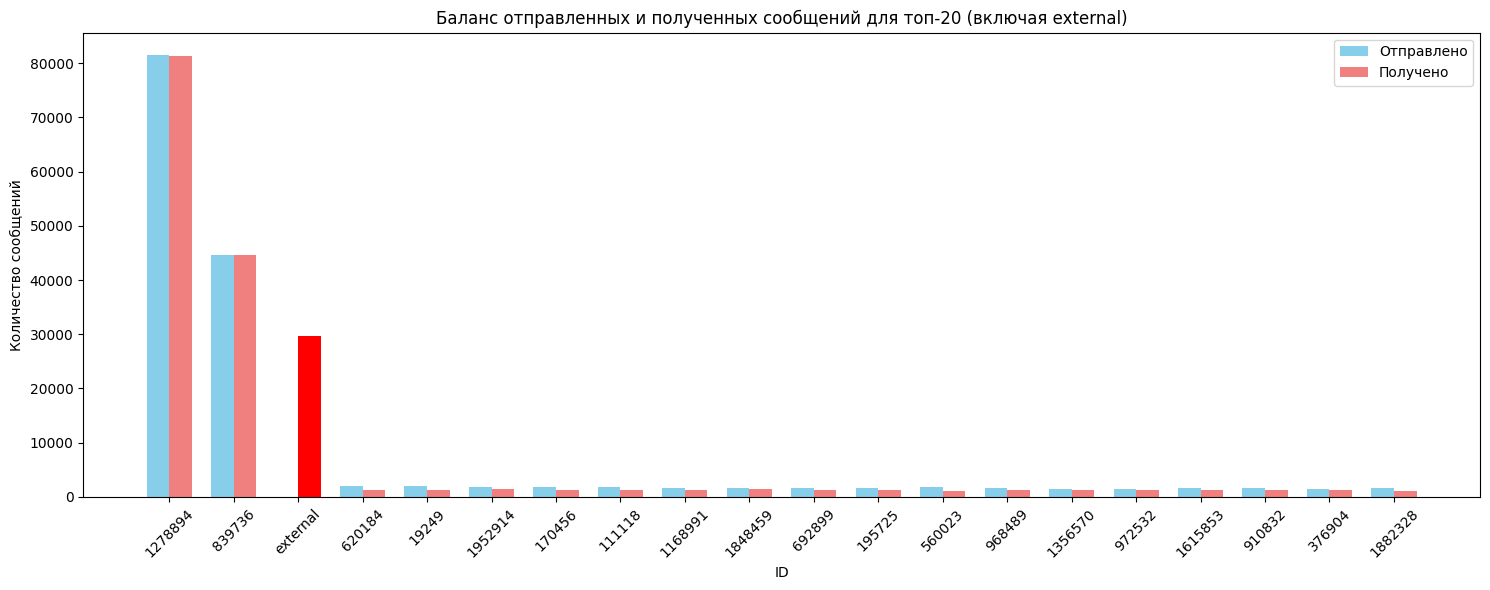

In [ ]:
df_sun_clean = df_sun.copy()
df_sun_clean['from'] = df_sun_clean['from'].astype(str)
df_sun_clean['to'] = df_sun_clean['to'].astype(str)

all_ids = pd.unique(pd.concat([df_sun_clean['from'], df_sun_clean['to']]))

# Функция для безопасного преобразования в int
def safe_int_conversion(x):
    try:
        return int(x)
    except (ValueError, TypeError):
        return x  # оставляем как есть (например, 'external')

# Применяем безопасное преобразование
all_ids = [safe_int_conversion(x) for x in all_ids]

all_ids_clean = [str(x) for x in all_ids]


# подсчет отправленных сообщений по каждому отправителю
sent_counts_str = df_sun_clean.groupby('from').size().reset_index()
sent_counts_str.columns = ['id', 'sent']
sent_counts_str['id'] = sent_counts_str['id'].astype(str)
sent_counts_str = sent_counts_str.set_index('id')

# подсчет полученных сообщений по каждому получателю
received_counts_str = df_sun_clean.groupby('to').size().reset_index()
received_counts_str.columns = ['id', 'received']
received_counts_str['id'] = received_counts_str['id'].astype(str)
received_counts_str = received_counts_str.set_index('id')

comparison_df_str = pd.DataFrame({'id': all_ids_clean}).set_index('id')
# объединяем все ID с количеством отправленных и полученных сообщений
comparison_df_str = comparison_df_str.join(sent_counts_str, how='left')
comparison_df_str = comparison_df_str.join(received_counts_str, how='left')
comparison_df_str = comparison_df_str.fillna(0).reset_index()

comparison_df_str['total'] = comparison_df_str['sent'] + comparison_df_str['received']
top_all = comparison_df_str.nlargest(20, 'total')

fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(top_all))
width = 0.35

colors_sent = ['darkorange' if id == 'external' else 'skyblue' for id in top_all['id']]
colors_rec = ['red' if id == 'external' else 'lightcoral' for id in top_all['id']]

ax.bar(x - width/2, top_all['sent'], width, label='Отправлено', color=colors_sent)
ax.bar(x + width/2, top_all['received'], width, label='Получено', color=colors_rec)

ax.set_xlabel('ID')
ax.set_ylabel('Количество сообщений')
ax.set_title('Баланс отправленных и полученных сообщений для топ-20 (включая external)')
ax.set_xticks(x)
ax.set_xticklabels(top_all['id'], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

### Рассмотрим на шкале активности отправителя **1278894**   
###   **Гипотеза о рассылке подтверждается**: Данный ID вероятно представляет собой автоматическую систему оповещения парка, которая регулярно рассылает информацию посетителям (расписание шоу, объявления, изменения в работе аттракционов). Полученные сообщения - это, вероятно, автоматические подтверждения доставки или ответы на опросы.

### Рассмотрим отправителя **External** на шкалах и столбчатой диаграмме
### Этот отправитель исключительно получает сообщения из-за пределов парка, но не отправляет ничего. В пятницу и субботу он получает сообщения равномерно, в воскресенье получает крайне много сообщений примерно в 11-45 утра.
### **Гипотеза 1**: External - это некий сервер, находящийся за пределами парка, через который проходит отправка постов в соц. сети со стороны посетителей (лично на устройство сервер не отправляет запросы в ответ, а передает маршрутизаторам, поэтому ответов от него нет).
###  **Гипотеза 2 (подробнее рассмотрена в файлах patterns и sunday_crime)**: Внезапный всплеск сообщений во внешний мир в 11-45 утра в воскресенье означает, что в парке произошло событие, о котором посетители начали массово сообщать за его пределы - звонки, сообщения в соцсети, мессенджеры. Это классический паттерн поведения очевидцев происшествия.

# **Сеть коммуникаций топ-отправителей**

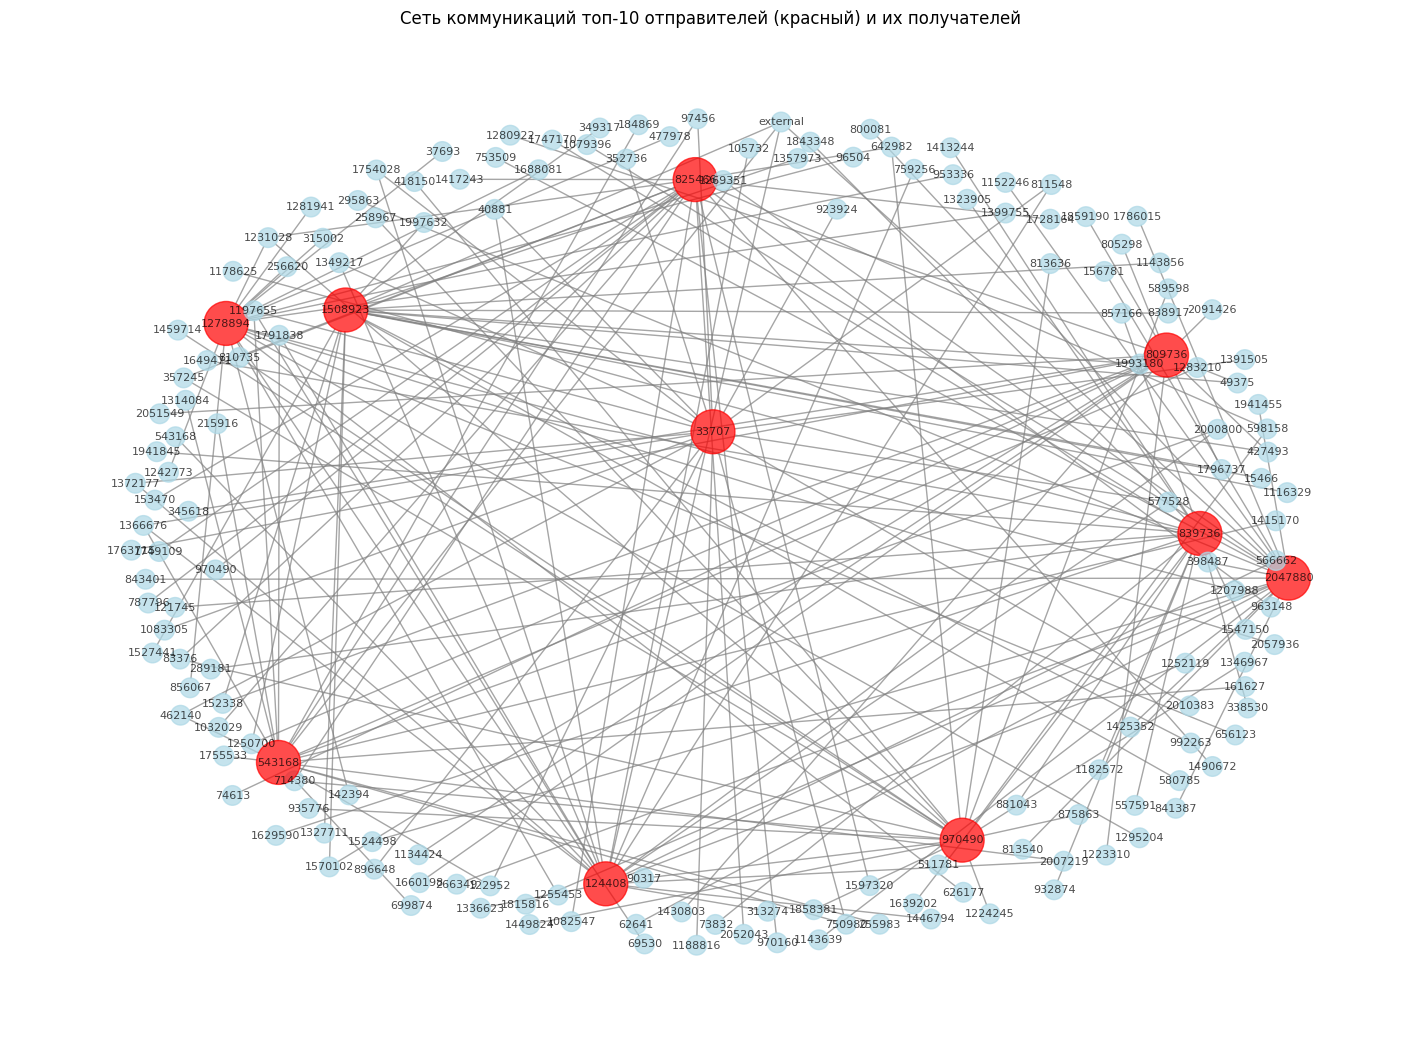

In [ ]:
import networkx as nx

# отельный подграф для топ-10 отправителей
top_senders = massage_counts_fri.head(10).index.tolist()
G_top = nx.Graph()

for sender in top_senders:
    # кому пишет этот отправитель
    recipients = df_fri[df_fri['from'] == sender]['to'].tolist()
    for recipient in recipients[:20]:
        G_top.add_edge(sender, recipient)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G_top, k=2, iterations=50)

# красный для топ-отправителей, голубой для получателей
node_colors = []
node_sizes = []
for node in G_top.nodes():
    if node in top_senders:
        node_colors.append('red')
        node_sizes.append(1000)
    else:
        node_colors.append('lightblue')
        node_sizes.append(200)

nx.draw(G_top, pos,
        node_color=node_colors,
        node_size=node_sizes,
        with_labels=True,
        font_size=8,
        edge_color='gray',
        alpha=0.7,
        arrows=True)

plt.title("Сеть коммуникаций топ-10 отправителей (красный) и их получателей")
plt.show()

# **Тепловая карта корреляций между отправителями в воскресенье**

In [ ]:
!pip install python-louvain

In [ ]:
import community.community_louvain as community_louvain

In [ ]:
# Функция для анализа сообществ одного дня
def analyze_day_communities(df_day, day_name):
    print(f"\n{'='*60}")
    print(f"АНАЛИЗ СООБЩЕСТВ - {day_name}")
    print('='*60)

    # Создаем граф для этого дня
    edges = df_day.groupby(["from", "to"]).size().reset_index(name="weight")

    G = nx.from_pandas_edgelist(
        edges,
        source="from",
        target="to",
        edge_attr="weight",
        create_using=nx.Graph()
    )

    print(f"Узлов: {G.number_of_nodes()}, Рёбер: {G.number_of_edges()}")

    # Поиск сообществ
    partition = community_louvain.best_partition(G, weight="weight")
    print(f"Найдено сообществ: {len(set(partition.values()))}")

    # Добавляем сообщества в датафрейм
    df_day = df_day.copy()
    df_day["from_comm"] = df_day["from"].map(partition)
    df_day["to_comm"] = df_day["to"].map(partition)

    # Находим специальные сообщества
    external_comm = None
    if "external" in df_day["to"].values:
        ext_comms = df_day.loc[df_day["to"] == "external", "to_comm"].dropna().unique()
        external_comm = ext_comms[0] if len(ext_comms) > 0 else None

    spamer_comm = None
    if 1278894 in df_day["from"].values:
        spam_comms = df_day.loc[df_day["from"] == 1278894, "from_comm"].dropna().unique()
        spamer_comm = spam_comms[0] if len(spam_comms) > 0 else None

    print(f"Сообщество спамера 1278894: {spamer_comm}")
    print(f"Сообщество external: {external_comm}")

    # Размеры сообществ
    community_sizes = df_day["from_comm"].value_counts()
    print(f"\nТоп-5 самых больших сообществ:")
    for comm, size in community_sizes.head(5).items():
        print(f"  Сообщество {comm}: {size} участников")

    # Внутренние сообщения
    internal_msgs = df_day[df_day["from_comm"] == df_day["to_comm"]].groupby("from_comm").size()

    return df_day, partition

In [ ]:
# анализ для каждого дня
# Пятница
df_fri_with_comm, partition_fri = analyze_day_communities(df_fri_processed, "ПЯТНИЦА")

# Суббота
df_sat_with_comm, partition_sat = analyze_day_communities(df_sat_processed, "СУББОТА")

# Воскресенье
df_sun_with_comm, partition_sun = analyze_day_communities(df_sun_processed, "ВОСКРЕСЕНЬЕ")


АНАЛИЗ СООБЩЕСТВ - ПЯТНИЦА
Узлов: 5876, Рёбер: 167760
Найдено сообществ: 42
Сообщество спамера 1278894: 13
Сообщество external: 13

Топ-5 самых больших сообществ:
  Сообщество 13: 122972 участников
  Сообщество 0: 101182 участников
  Сообщество 8: 67075 участников
  Сообщество 4: 64104 участников
  Сообщество 5: 63981 участников

АНАЛИЗ СООБЩЕСТВ - СУББОТА
Узлов: 10525, Рёбер: 302824
Найдено сообществ: 123
Сообщество спамера 1278894: 111
Сообщество external: 80

Топ-5 самых больших сообществ:
  Сообщество 80: 161366 участников
  Сообщество 111: 121438 участников
  Сообщество 14: 95880 участников
  Сообщество 38: 88458 участников
  Сообщество 7: 76820 участников

АНАЛИЗ СООБЩЕСТВ - ВОСКРЕСЕНЬЕ
Узлов: 12158, Рёбер: 276045
Найдено сообществ: 81
Сообщество спамера 1278894: 22
Сообщество external: 2

Топ-5 самых больших сообществ:
  Сообщество 62: 263277 участников
  Сообщество 2: 143921 участников
  Сообщество 22: 133793 участников
  Сообщество 10: 76904 участников
  Сообщество 1: 76320 у

In [ ]:
# матрица корреляций активности отправителей
df = df_sun_with_comm.copy()
message_counts = df['from'].value_counts()
top_10_senders = message_counts.head(10).index.tolist()

# матрица активности по 15-минутным интервалам
activity_matrix = pd.DataFrame(index=df['quarter'].unique())

for sender in top_10_senders:
    sender_activity = df[df['from'] == sender].groupby('quarter').size()
    activity_matrix[sender] = sender_activity

activity_matrix = activity_matrix.fillna(0).T

correlation_matrix = activity_matrix.T.corr()

# тепловая карта корреляций
fig = go.Figure(data=go.Heatmap(
    z=correlation_matrix.values,
    x=[f'ID {i}' for i in correlation_matrix.columns],
    y=[f'ID {i}' for i in correlation_matrix.index],
    colorscale='RdBu_r',
    zmid=0,
    text=correlation_matrix.values.round(2),
    texttemplate='%{text}',
    textfont={"size": 10},
    hoverinfo='text'
))

fig.update_layout(
    title='Корреляция активности между топ-10 отправителями',
    width=900,
    height=700
)

fig.show()